# 07. Model Evaluation

Compare model quality using precision, recall, F1, PR curves, and confusion matrices.

# 07 — Final Model Evaluation

## Objectives

1. Compare all trained models
2. Evaluate using fraud-appropriate metrics
3. Select the operating threshold using validation data
4. Evaluate the final model on the untouched test set
5. Analyze false positives and false negatives
6. Measure inference latency
7. Select the production model

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system


In [10]:
from src.inference.predictor import FraudPredictor

predictor = FraudPredictor()

print("Model loaded successfully!")
print("Threshold:", predictor.threshold)
print("Features:", predictor.model.n_features_in_)

Model loaded successfully!
Threshold: 0.56
Features: 30


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

In [4]:
DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


In [5]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (199364, 30)
Validation: (42721, 30)
Test: (42722, 30)


In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [17]:
xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]

lgbm_val_prob = lgbm_model.predict_proba(X_val)[:, 1]

In [18]:
xgb_val_pr_auc = average_precision_score(
    y_val,
    xgb_val_prob
)

lgbm_val_pr_auc = average_precision_score(
    y_val,
    lgbm_val_prob
)

print("XGBoost Validation PR-AUC:", xgb_val_pr_auc)
print("LightGBM Validation PR-AUC:", lgbm_val_pr_auc)

XGBoost Validation PR-AUC: 0.822479959006669
LightGBM Validation PR-AUC: 0.2981497424579909


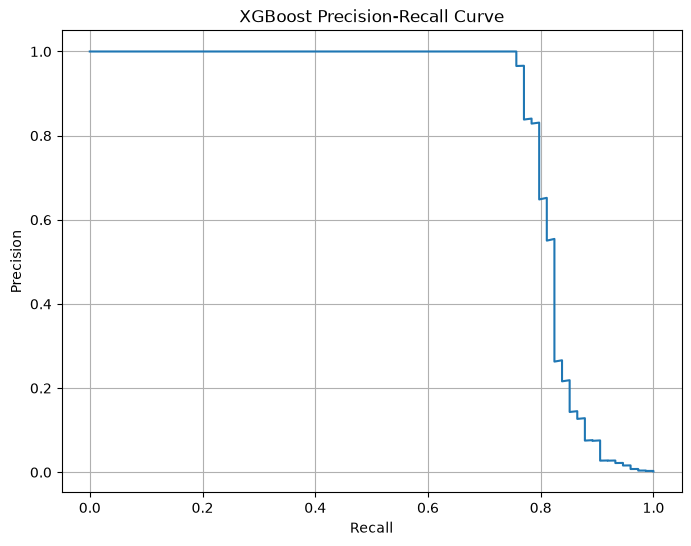

In [19]:
precision, recall, thresholds = precision_recall_curve(
    y_val,
    xgb_val_prob
)
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost Precision-Recall Curve")

plt.grid()
plt.show()

In [20]:
thresholds_to_test = np.arange(
    0.01,
    1.00,
    0.01
)
threshold_results = []

for threshold in thresholds_to_test:

    predictions = (
        xgb_val_prob >= threshold
    ).astype(int)

    precision_value = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1_value = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1": f1_value
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.01,0.508333,0.824324,0.628866
1,0.02,0.618557,0.810811,0.701754
2,0.03,0.670455,0.797297,0.728395
3,0.04,0.686047,0.797297,0.737500
4,0.05,0.728395,0.797297,0.761290


In [21]:
best_f1_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_f1_row
best_threshold = best_f1_row["Threshold"]

print(
    "Best threshold:",
    best_threshold
)

Best threshold: 0.56


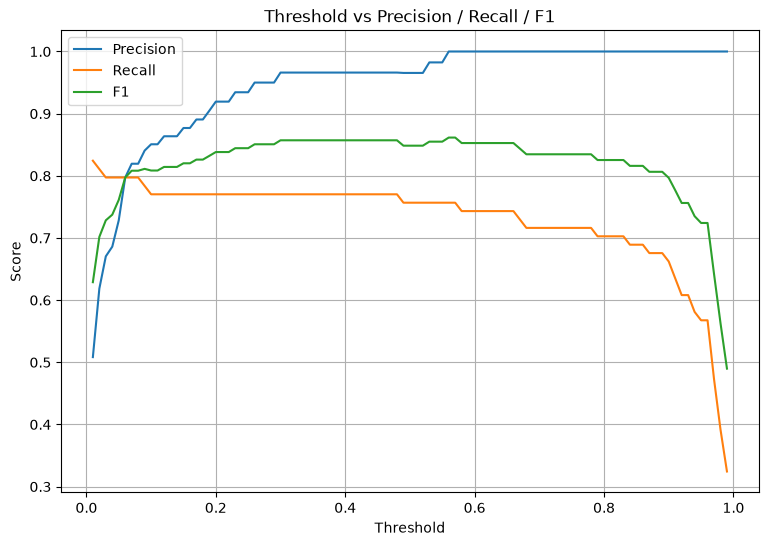

In [22]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1")

plt.legend()
plt.grid()

plt.show()

In [23]:
target_recall = 0.90

eligible = threshold_df[
    threshold_df["Recall"] >= target_recall
]

eligible.sort_values(
    "Precision",
    ascending=False
).head(10)

,Threshold,Precision,Recall,F1


In [24]:
final_threshold = best_threshold

print(
    "Selected threshold:",
    final_threshold
)

Selected threshold: 0.56


In [25]:
xgb_test_prob = xgb_model.predict_proba(
    X_test
)[:, 1]
xgb_test_pred = (
    xgb_test_prob >= final_threshold
).astype(int)

In [26]:
final_accuracy = accuracy_score(
    y_test,
    xgb_test_pred
)

final_precision = precision_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    xgb_test_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    xgb_test_prob
)

final_pr_auc = average_precision_score(
    y_test,
    xgb_test_prob
)

In [27]:
print("FINAL XGBOOST RESULTS")
print("---------------------")
print("Threshold :", final_threshold)
print("Accuracy  :", final_accuracy)
print("Precision :", final_precision)
print("Recall    :", final_recall)
print("F1        :", final_f1)
print("ROC-AUC   :", final_roc_auc)
print("PR-AUC    :", final_pr_auc)

FINAL XGBOOST RESULTS
---------------------
Threshold : 0.56
Accuracy  : 0.9995318571227939
Precision : 0.9354838709677419
Recall    : 0.7837837837837838
F1        : 0.8529411764705882
ROC-AUC   : 0.9647393242989755
PR-AUC    : 0.835762564195154


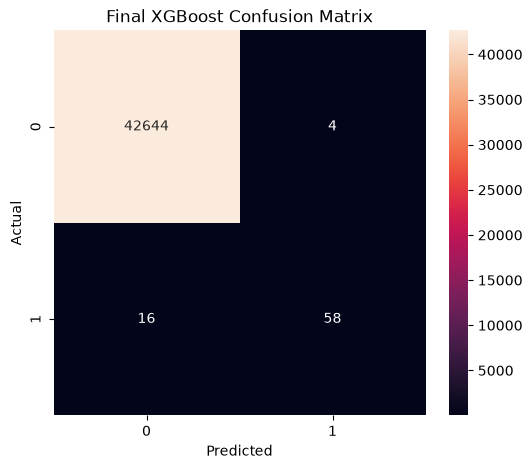

In [28]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Confusion Matrix")

plt.show()

In [29]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=[
            "Legitimate",
            "Fraud"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42648
       Fraud       0.94      0.78      0.85        74

    accuracy                           1.00     42722
   macro avg       0.97      0.89      0.93     42722
weighted avg       1.00      1.00      1.00     42722



In [30]:
false_negatives = X_test[
    (y_test == 1) &
    (xgb_test_pred == 0)
]

print(
    "False negatives:",
    len(false_negatives)
)
false_positives = X_test[
    (y_test == 0) &
    (xgb_test_pred == 1)
]

print(
    "False positives:",
    len(false_positives)
)

False negatives: 16
False positives: 4


In [31]:
single_transaction = X_test.iloc[[0]]
xgb_model.predict_proba(
    single_transaction
)
iterations = 1000

start = time.perf_counter()

for _ in range(iterations):
    xgb_model.predict_proba(
        single_transaction
    )

end = time.perf_counter()

total_time = end - start

average_latency_ms = (
    total_time / iterations
) * 1000

print(
    "Average inference latency:",
    average_latency_ms,
    "ms"
)

Average inference latency: 2.7056671000027563 ms


In [32]:
start = time.perf_counter()

for _ in range(iterations):
    lgbm_model.predict_proba(
        single_transaction
    )

end = time.perf_counter()

lgbm_latency_ms = (
    (end - start) / iterations
) * 1000

print(
    "LightGBM latency:",
    lgbm_latency_ms,
    "ms"
)

LightGBM latency: 1.388257300000987 ms


In [33]:
latency_df = pd.DataFrame([
    {
        "Model": "XGBoost",
        "Latency_ms": average_latency_ms
    },
    {
        "Model": "LightGBM",
        "Latency_ms": lgbm_latency_ms
    }
])

latency_df

,Model,Latency_ms
0,XGBoost,2.705667
1,LightGBM,1.388257


In [34]:
final_comparison = pd.DataFrame([
    {
        "Model": "XGBoost",
        "PR-AUC": average_precision_score(
            y_test,
            xgb_test_prob
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            xgb_test_prob
        ),
        "Precision": precision_score(
            y_test,
            xgb_test_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            xgb_test_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            xgb_test_pred,
            zero_division=0
        ),
        "Latency_ms": average_latency_ms
    }
])

final_comparison

,Model,PR-AUC,ROC-AUC,Precision,Recall,F1,Latency_ms
0,XGBoost,0.835763,0.964739,0.935484,0.783784,0.852941,2.705667


In [35]:
final_comparison.to_csv(
    "../data/processed/final_model_results.csv",
    index=False
)

In [36]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained XGBoost model
joblib.dump(
    xgb_model,
    "../models/xgboost_fraud_model.pkl"
)
print("✓ Model saved: ../models/xgboost_fraud_model.pkl")

# Save the scaler for preprocessing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)
print("✓ Scaler saved: ../models/scaler.pkl")

# Save the optimal threshold
with open(
    "../models/threshold.txt",
    "w"
) as f:
    f.write(str(final_threshold))

print("✓ Threshold saved: ../models/threshold.txt")
print(f"  Threshold value: {final_threshold}")

✓ Model saved: ../models/xgboost_fraud_model.pkl
✓ Scaler saved: ../models/scaler.pkl
✓ Threshold saved: ../models/threshold.txt
  Threshold value: 0.56


In [37]:
import joblib
import os

model_path = "../models/xgboost_fraud_model.pkl"
scaler_path = "../models/scaler.pkl"
threshold_path = "../models/threshold.txt"

print("Model exists:", os.path.exists(model_path))
print("Scaler exists:", os.path.exists(scaler_path))
print("Threshold exists:", os.path.exists(threshold_path))

Model exists: True
Scaler exists: True
Threshold exists: True


In [38]:
loaded_model = joblib.load(
    "../models/xgboost_fraud_model.pkl"
)

loaded_scaler = joblib.load(
    "../models/scaler.pkl"
)

with open("../models/threshold.txt", "r") as f:
    loaded_threshold = float(f.read())

print("Threshold:", loaded_threshold)

Threshold: 0.56


In [39]:
sample = X_test.iloc[[0]]

print(sample.shape)
sample_scaled = loaded_scaler.transform(sample)
probability = loaded_model.predict_proba(
    sample_scaled
)[:, 1][0]

prediction = int(
    probability >= loaded_threshold
)

print("Fraud probability:", probability)
print("Prediction:", prediction)

(1, 30)
Fraud probability: 2.117275e-05
Prediction: 0


In [40]:
sample = X_test.iloc[[0]]

probability = loaded_model.predict_proba(
    sample
)[:, 1][0]

prediction = int(
    probability >= loaded_threshold
)

print("Fraud probability:", probability)
print("Prediction:", prediction)

Fraud probability: 8.8222833e-07
Prediction: 0


In [41]:
original_probability = xgb_model.predict_proba(
    sample
)[:, 1][0]

loaded_probability = loaded_model.predict_proba(
    sample
)[:, 1][0]

print("Original :", original_probability)
print("Loaded   :", loaded_probability)

print(
    "Difference:",
    abs(
        original_probability -
        loaded_probability
    )
)

Original : 8.8222833e-07
Loaded   : 8.8222833e-07
Difference: 0.0


In [42]:
from src.inference.predictor import FraudPredictor

predictor = FraudPredictor()

print("Model loaded successfully")
print("Threshold:", predictor.threshold)
print("Expected features:", predictor.model.n_features_in_)

Model loaded successfully
Threshold: 0.56
Expected features: 30


In [43]:
import os

print(os.getcwd())

c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks


In [44]:
import sys

print(sys.executable)


c:\Users\nikhi\AppData\Local\Programs\Python\Python312\python.exe


In [45]:
import os

print(os.path.exists("../src"))
print(os.path.exists("src"))

True
False


In [46]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(sys.path[0])

c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system


In [47]:
from src.inference.predictor import FraudPredictor
predictor = FraudPredictor()

print("Model loaded successfully!")
print("Threshold:", predictor.threshold)
print("Expected features:", predictor.model.n_features_in_)

Model loaded successfully!
Threshold: 0.56
Expected features: 30


In [48]:
from pathlib import Path

print("Current directory:")
print(Path.cwd())

print("\nFiles/folders here:")
for item in Path.cwd().iterdir():
    print(item)

Current directory:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks

Files/folders here:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\01_data_understanding.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\02_eda.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\03_feature_engineering.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\04_baseline_models.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\05_xgboost_lightgbm.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\06_anomaly_detection.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\07_model_evaluation.ipynb


In [49]:
import os
import sys
from pathlib import Path

print("Current directory:")
print(os.getcwd())

print("\nPython:")
print(sys.executable)

print("\nCurrent directory contents:")
for item in Path.cwd().iterdir():
    print(item)

Current directory:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks

Python:
c:\Users\nikhi\AppData\Local\Programs\Python\Python312\python.exe

Current directory contents:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\01_data_understanding.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\02_eda.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\03_feature_engineering.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\04_baseline_models.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\05_xgboost_lightgbm.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\06_anomaly_detection.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\07_model_evaluation.ipynb


In [50]:
import os
import sys
from pathlib import Path

print("Current directory:")
print(os.getcwd())

print("\nPython:")
print(sys.executable)

print("\nCurrent directory contents:")
for item in Path.cwd().iterdir():
    print(item)

Current directory:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks

Python:
c:\Users\nikhi\AppData\Local\Programs\Python\Python312\python.exe

Current directory contents:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\01_data_understanding.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\02_eda.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\03_feature_engineering.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\04_baseline_models.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\05_xgboost_lightgbm.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\06_anomaly_detection.ipynb
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks\07_model_evaluation.ipynb


In [51]:
import os
import sys
from pathlib import Path

print("Current directory:")
print(os.getcwd())

print("\nPython executable:")
print(sys.executable)

print("\nCurrent directory contents:")
for item in Path.cwd().iterdir():
    print(f"  {item.name}")
    
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)
print(f"Threshold: {final_threshold}")
print(f"Accuracy:  {final_accuracy}")
print(f"Precision: {final_precision}")
print(f"Recall:    {final_recall}")
print(f"F1:        {final_f1}")
print(f"ROC-AUC:   {final_roc_auc}")
print(f"PR-AUC:    {final_pr_auc}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nFalse Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

Current directory:
c:\Users\nikhi\OneDrive\New folder\mlfraud.py\fraud-detection-system\notebooks

Python executable:
c:\Users\nikhi\AppData\Local\Programs\Python\Python312\python.exe

Current directory contents:
  01_data_understanding.ipynb
  02_eda.ipynb
  03_feature_engineering.ipynb
  04_baseline_models.ipynb
  05_xgboost_lightgbm.ipynb
  06_anomaly_detection.ipynb
  07_model_evaluation.ipynb

MODEL EVALUATION RESULTS
Threshold: 0.56
Accuracy:  0.9995318571227939
Precision: 0.9354838709677419
Recall:    0.7837837837837838
F1:        0.8529411764705882
ROC-AUC:   0.9647393242989755
PR-AUC:    0.835762564195154

Confusion Matrix:
[[42644     4]
 [   16    58]]

False Positives: 4
False Negatives: 16


In [52]:
import sys

print(sys.executable)

c:\Users\nikhi\AppData\Local\Programs\Python\Python312\python.exe


In [53]:
sample_transaction = X_test.iloc[0].values

print("Number of features:", len(sample_transaction))

Number of features: 30


In [54]:
result = predictor.predict(sample_transaction)

print(result)

{'fraud_probability': 8.822283348308702e-07, 'threshold': 0.56, 'prediction': 0, 'is_fraud': False}


In [55]:
original_probability = (
    xgb_model
    .predict_proba(
        X_test.iloc[[0]]
    )[:, 1][0]
)

predictor_probability = result["fraud_probability"]

print("Original probability :", original_probability)
print("Predictor probability:", predictor_probability)

print(
    "Difference:",
    abs(
        original_probability -
        predictor_probability
    )
)

Original probability : 8.8222833e-07
Predictor probability: 8.822283348308702e-07
Difference: 0.0


In [56]:
original_prediction = int(
    original_probability >= final_threshold
)

predictor_prediction = result["prediction"]

print("Original prediction :", original_prediction)
print("Predictor prediction:", predictor_prediction)

Original prediction : 0
Predictor prediction: 0


In [57]:
sample = X_test.iloc[0]

print(sample.to_dict())

{'Time': 148580.0, 'V1': -1.08860252327554, 'V2': 0.227684493717604, 'V3': 1.70446423633482, 'V4': -2.35333183593795, 'V5': -0.0205756088947456, 'V6': -0.172106743175544, 'V7': 0.583031671396642, 'V8': 0.0617329021383216, 'V9': 0.239968628337737, 'V10': -1.31502430302492, 'V11': 0.656777603828121, 'V12': 0.764813769585199, 'V13': 0.407951980688857, 'V14': -0.156424317805708, 'V15': -0.0674871993672851, 'V16': 0.631197952122071, 'V17': -1.08135240543906, 'V18': 0.632738493297563, 'V19': -0.121099129343154, 'V20': -0.0738035734416213, 'V21': 0.217620686602102, 'V22': 0.653238021876026, 'V23': -0.327775067273328, 'V24': -0.315683709621901, 'V25': 0.583261642757641, 'V26': 0.743449612737544, 'V27': -0.120431966266262, 'V28': 0.0051651175831809, 'Amount': 60.0}


In [7]:
fraud_sample = X_test[y_test == 1].iloc[0]

print(fraud_sample)

Time      169347.000000
V1             1.378559
V2             1.289381
V3            -5.004247
V4             1.411850
V5             0.442581
V6            -1.326536
V7            -1.413170
V8             0.248525
V9            -1.127396
V10           -3.232153
V11            2.858466
V12           -3.096915
V13           -0.792532
V14           -5.210141
V15           -0.613803
V16           -2.155297
V17           -3.267116
V18           -0.688505
V19            0.737657
V20            0.226138
V21            0.370612
V22            0.028234
V23           -0.145640
V24           -0.081049
V25            0.521875
V26            0.739467
V27            0.389152
V28            0.186637
Amount         0.760000
Name: 280143, dtype: float64


In [8]:
# Find one legitimate transaction
legit_sample = X_test[y_test == 0].iloc[0]

# Find one fraudulent transaction
fraud_sample = X_test[y_test == 1].iloc[0]

print("LEGITIMATE SAMPLE")
print(legit_sample.to_dict())

print("\nFRAUD SAMPLE")
print(fraud_sample.to_dict())

print("\nLabels:")
print("Legitimate:", y_test.loc[legit_sample.name])
print("Fraud:", y_test.loc[fraud_sample.name])

LEGITIMATE SAMPLE
{'Time': 148580.0, 'V1': -1.08860252327554, 'V2': 0.227684493717604, 'V3': 1.70446423633482, 'V4': -2.35333183593795, 'V5': -0.0205756088947456, 'V6': -0.172106743175544, 'V7': 0.583031671396642, 'V8': 0.0617329021383216, 'V9': 0.239968628337737, 'V10': -1.31502430302492, 'V11': 0.656777603828121, 'V12': 0.764813769585199, 'V13': 0.407951980688857, 'V14': -0.156424317805708, 'V15': -0.0674871993672851, 'V16': 0.631197952122071, 'V17': -1.08135240543906, 'V18': 0.632738493297563, 'V19': -0.121099129343154, 'V20': -0.0738035734416213, 'V21': 0.217620686602102, 'V22': 0.653238021876026, 'V23': -0.327775067273328, 'V24': -0.315683709621901, 'V25': 0.583261642757641, 'V26': 0.743449612737544, 'V27': -0.120431966266262, 'V28': 0.0051651175831809, 'Amount': 60.0}

FRAUD SAMPLE
{'Time': 169347.0, 'V1': 1.37855899734127, 'V2': 1.28938093711056, 'V3': -5.00424678441137, 'V4': 1.4118498419441, 'V5': 0.442580635567782, 'V6': -1.3265359338336, 'V7': -1.41316995590712, 'V8': 0.2485